# Homework 08 (Colab): линейная алгебра и OLS

Решения заданий из [Colab-ноутбука](https://colab.research.google.com/drive/1tRnpjwp_QoSxpIlgP7TTl2YmIOa7_Ih-).


# **Общие рекомендации**


* Решения заданий ожидаются в формате ноутбука (Jupyter/Colab).

* Формулы желательно оформлять с использование [latex-markdown](https://colab.research.google.com/notebooks/markdown_guide.ipynb).

* Задание 8 не влияет на оценивание, но может быть выполнено вами ради интереса и получения математически-эстетического удовольствия ☺️.


# **Задания**


---

### Задание 1.


Известно, что $g(x) = 2^x + 1$. Вычислите численное значение $g(g(2))$.


**Решение.**

$$
g(2) = 2^2 + 1 = 5,
\qquad
g(g(2)) = g(5) = 2^5 + 1 = 33.
$$

**Ответ:** $33$.


In [1]:
def g(x):
    return 2 ** x + 1

assert g(g(2)) == 33
print(g(g(2)))

33


---

### Задание 2.


Даны матрицы:

$$
A = \begin{pmatrix}
2 & -4 \\
3 & 5 \\
-1 & 0
\end{pmatrix}, \quad
B = \begin{pmatrix}
1 & 2 & 7 \\
-3 & -4 & 0 \\
5 & 2 & 1
\end{pmatrix}, \quad
C = \begin{pmatrix}
6 & -3 & 9 \\
4 & -5 & 2 \\
8 & 1 & 5
\end{pmatrix}.
$$

Посчитайте матрицу $D = A^T C - 2A^T B^T$.  
Приведите полную последовательность вычислений.


**Решение.**

$$
A^T =
\begin{pmatrix}
2 & 3 & -1 \\
-4 & 5 & 0
\end{pmatrix},
\qquad
B^T =
\begin{pmatrix}
1 & -3 & 5 \\
2 & -4 & 2 \\
7 & 0 & 1
\end{pmatrix}.
$$

$$
A^T C =
\begin{pmatrix}
2\cdot6+3\cdot4+(-1)\cdot8 & 2\cdot(-3)+3\cdot(-5)+(-1)\cdot1 & 2\cdot9+3\cdot2+(-1)\cdot5 \\
-4\cdot6+5\cdot4+0\cdot8 & -4\cdot(-3)+5\cdot(-5)+0\cdot1 & -4\cdot9+5\cdot2+0\cdot5
\end{pmatrix}
=
\begin{pmatrix}
16 & -22 & 19 \\
-4 & -13 & -26
\end{pmatrix}.
$$

$$
A^T B^T =
\begin{pmatrix}
2\cdot1+3\cdot2+(-1)\cdot7 & 2\cdot(-3)+3\cdot(-4)+(-1)\cdot0 & 2\cdot5+3\cdot2+(-1)\cdot1 \\
-4\cdot1+5\cdot2+0\cdot7 & -4\cdot(-3)+5\cdot(-4)+0\cdot0 & -4\cdot5+5\cdot2+0\cdot1
\end{pmatrix}
=
\begin{pmatrix}
1 & -18 & 15 \\
6 & -8 & -10
\end{pmatrix}.
$$

$$
2A^T B^T =
\begin{pmatrix}
2 & -36 & 30 \\
12 & -16 & -20
\end{pmatrix}.
$$

$$
D = A^T C - 2A^T B^T =
\begin{pmatrix}
16-2 & -22-(-36) & 19-30 \\
-4-12 & -13-(-16) & -26-(-20)
\end{pmatrix}
=
\begin{pmatrix}
14 & 14 & -11 \\
-16 & 3 & -6
\end{pmatrix}.
$$


In [2]:
import numpy as np

A = np.array([[2, -4], [3, 5], [-1, 0]])
B = np.array([[1, 2, 7], [-3, -4, 0], [5, 2, 1]])
C = np.array([[6, -3, 9], [4, -5, 2], [8, 1, 5]])

D = A.T @ C - 2 * (A.T @ B.T)
print(D)
assert np.array_equal(D, np.array([[14, 14, -11], [-16, 3, -6]]))

[[ 14  14 -11]
 [-16   3  -6]]


---

### Задание 3.


Дано выражение:

$$
3 \cdot \begin{pmatrix}
x & 2 & 3 \\
-1 & y & 4
\end{pmatrix}
+ 2 \cdot \begin{pmatrix}
1 & 2 & -5 \\
2 & -6 & z
\end{pmatrix}
= \begin{pmatrix}
8 & v & -1 \\
1 & 6 & 4
\end{pmatrix}.
$$

Найдите значения $(x, y, z)$ и $v$, при которых выражение верно.


**Решение.** Левая часть:

$$
\begin{pmatrix}
3x+2 & 10 & -1 \\
1 & 3y-12 & 12+2z
\end{pmatrix}
=
\begin{pmatrix}
8 & v & -1 \\
1 & 6 & 4
\end{pmatrix}.
$$

Отсюда:
- $3x + 2 = 8 \Rightarrow x = 2$
- $v = 10$
- $3y - 12 = 6 \Rightarrow y = 6$
- $12 + 2z = 4 \Rightarrow z = -4$

**Ответ:** $x=2$, $y=6$, $z=-4$, $v=10$.


---

### Задания 4–5.


На координатной плоскости отмечены точки $(-3, 2)$, $(2, 2)$, $(5, -3)$.

Нужно найти прямую через $(0,0)$, минимизирующую:

4) сумму отклонений по $y$;

5) сумму квадратов отклонений по $y$.


#### Задание 4 (сумма отклонений)

**Шаг 1.** Прямая через начало координат: $y = kx$ (один параметр $k$).

**Шаг 2.** Целевая функция:
$$
L(k) = \sum_i |y_i - k x_i| = |2 + 3k| + |2 - 2k| + |-3 - 5k|.
$$

Точки излома: $k = -\dfrac{2}{3}$, $k = -\dfrac{3}{5}$, $k = 1$.

**Шаг 3.** На интервалах:
- $k < -\frac{2}{3}$: $L'(k) = -10 < 0$ (убывает);
- $-\frac{2}{3} < k < -\frac{3}{5}$: $L'(k) = -4 < 0$ (убывает);
- $-\frac{3}{5} < k < 1$: $L'(k) = 6 > 0$ (растёт);
- $k > 1$: $L'(k) = 10 > 0$ (растёт).

Минимум в точке $k = -\dfrac{3}{5}$, значение $L\left(-\dfrac{3}{5}\right) = \dfrac{17}{5}$.

**Ответ:** $y = -\dfrac{3}{5}x$.


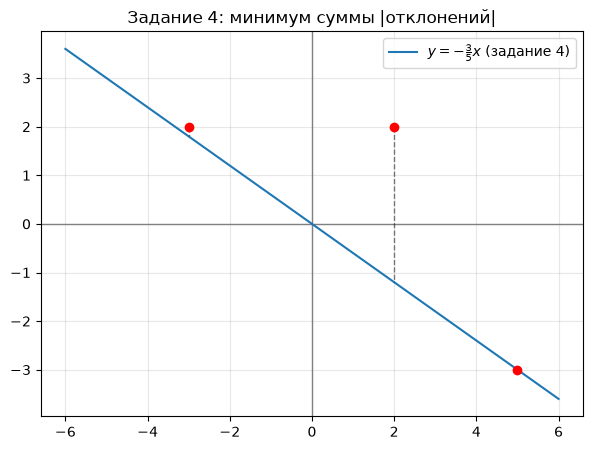

L = 3.4000000000000004


In [3]:
import matplotlib.pyplot as plt
import numpy as np

points = np.array([[-3, 2], [2, 2], [5, -3]])
k4 = -3 / 5

xs = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 5))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.plot(xs, k4 * xs, label=r'$y=-\frac{3}{5}x$ (задание 4)')
plt.scatter(points[:, 0], points[:, 1], color='red', zorder=5)
for x, y in points:
    plt.plot([x, x], [y, k4 * x], 'k--', lw=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Задание 4: минимум суммы |отклонений|')
plt.show()

L = abs(2 + 3 * k4) + abs(2 - 2 * k4) + abs(-3 - 5 * k4)
print('L =', L)

#### Задание 5 (сумма квадратов)

**Шаг 1.** Снова $y = kx$.

**Шаг 2.**
$$
Q(k) = (2 + 3k)^2 + (2 - 2k)^2 + (-3 - 5k)^2 = 38k^2 + 34k + 17.
$$

**Шаг 3.**
$$
Q'(k) = 76k + 34 = 0 \Rightarrow k = -\dfrac{17}{38}.
$$
Так как $Q''(k) = 76 > 0$, это минимум.

**Ответ:** $y = -\dfrac{17}{38}x$.


In [ ]:
k5 = -17 / 38
xs = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 5))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.plot(xs, k5 * xs, label=r'$y=-\frac{17}{38}x$ (задание 5)')
plt.scatter(points[:, 0], points[:, 1], color='red', zorder=5)
for x, y in points:
    plt.plot([x, x], [y, k5 * x], 'k--', lw=1, alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Задание 5: минимум суммы квадратов отклонений')
plt.show()

Q = ((points[:, 1] - k5 * points[:, 0]) ** 2).sum()
print('Q =', Q)

---

### Задание 6.


* Запишите матрично-векторное уравнение $Ax = b$ в виде системы линейных уравнений.
* Решите его, найдя вектор $x$.

$$
A =
\begin{pmatrix}
1 & 2 & 4 \\
2 & 1 & -1 \\
1 & -1 & 1
\end{pmatrix},
\qquad
b =
\begin{pmatrix}
3 \\ -9 \\ 0
\end{pmatrix}.
$$


**Система:**
$$
\begin{cases}
x_1 + 2x_2 + 4x_3 = 3, \\
2x_1 + x_2 - x_3 = -9, \\
x_1 - x_2 + x_3 = 0.
\end{cases}
$$

Из третьего уравнения: $x_1 = x_2 - x_3$.

Подставляем во второе:
$2(x_2 - x_3) + x_2 - x_3 = -9 \Rightarrow 3x_2 - 3x_3 = -9 \Rightarrow x_2 - x_3 = -3$.

Но $x_1 = x_2 - x_3$, значит $x_1 = -3$.

Тогда $x_2 = x_1 + x_3 = -3 + x_3$.

В первое: $-3 + 2(-3 + x_3) + 4x_3 = 3 \Rightarrow -3 - 6 + 2x_3 + 4x_3 = 3 \Rightarrow 6x_3 = 12 \Rightarrow x_3 = 2$.

Отсюда $x_2 = -3 + 2 = -1$.

**Ответ:** $x = (-3,\ -1,\ 2)^T$.


In [ ]:
A = np.array([[1, 2, 4], [2, 1, -1], [1, -1, 1]], dtype=float)
b = np.array([3, -9, 0], dtype=float)
x = np.linalg.solve(A, b)
print(x)
assert np.allclose(x, [-3, -1, 2])

---

### Задание 7.


Плотность — треугольник с гипотенузой $y = 2x$ на $[0, 1]$ (площадь $\frac12\cdot1\cdot2 = 1$).

То есть
$$
\rho(x) =
\begin{cases}
2x, & 0 \le x \le 1, \\
0, & \text{иначе}.
\end{cases}
$$

**7-1.**
$$
P(0 \le X \le 0.5) = \int_0^{0.5} 2x\,dx = x^2\Big|_0^{0.5} = 0.25.
$$

**7-2. CDF:**
$$
F(t) =
\begin{cases}
0, & t < 0, \\
t^2, & 0 \le t \le 1, \\
1, & t > 1.
\end{cases}
$$


In [ ]:
from scipy.integrate import quad

prob, _ = quad(lambda x: 2 * x, 0, 0.5)
print('P(0 <= X <= 0.5) =', prob)

def cdf(t):
    if t < 0:
        return 0.0
    if t > 1:
        return 1.0
    return t ** 2

print('F(0.5) =', cdf(0.5))

---

### Задание 8** (бонус).


Для всех прямых на плоскости (не только через $(0,0)$) используем МНК:
$$
w_{\min} = (X^T X)^{-1} X^T y,
$$
где строки $X$ имеют вид $(1,\ x_i)$, а $w = (w_0, w_1)^T$ задаёт $y = w_0 + w_1 x$.


In [ ]:
X = np.array([[1, -3], [1, 2], [1, 5]], dtype=float)
y = np.array([2, 2, -3], dtype=float)

w = np.linalg.inv(X.T @ X) @ (X.T @ y)
print('w =', w)
print('прямая: y = {} + ({}) * x'.format(w[0], w[1]))

# точные дроби: w0 = 53/49, w1 = -55/98
assert np.allclose(w, [53/49, -55/98])

xs = np.linspace(-6, 6, 200)
plt.figure(figsize=(7, 5))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.plot(xs, w[0] + w[1] * xs, label=r'$y=\frac{53}{49}-\frac{55}{98}x$')
plt.scatter([-3, 2, 5], [2, 2, -3], color='red', zorder=5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Задание 8: МНК по всем прямым')
plt.show()

**Ответ:** $y = \dfrac{53}{49} - \dfrac{55}{98}x$.
